## Machine Learning Credit Card Fraud Detection

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

In [2]:
# Set the working directory to the project folder
import os

os.chdir(r"C:\Users\Kaith\Desktop\Credit_Card_Fraud_Detection\Datasets")

In [4]:
# Confirm the current working directory and list the files
print(os.getcwd())
print(os.listdir())

C:\Users\Kaith\Desktop\Credit_Card_Fraud_Detection\Datasets
['credit_card_fraud_10k.csv', 'credit_card_fraud_cleaned.csv']


In [5]:
# Load the credit card fraud detection dataset
df = pd.read_csv("credit_card_fraud_cleaned.csv")

In [6]:
# Check the dataset demension
df.shape

(10000, 10)

In [7]:
# Display the first five rows
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [8]:
# Check the distribution of legitimate and fraudulent transactions
df["is_fraud"].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [9]:
# Select the features used to predict fraudulent transactions
X = df.drop(columns=["is_fraud", "transaction_id"])

# Selct the target variable
y = df["is_fraud"]

# Display the feature columns
X.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age'],
      dtype='str')

In [11]:
# Convert the categorical merchant_category variable into numerical columns
X = pd.get_dummies(X, columns=["merchant_category"], drop_first=True)

# Check the update feature set
X.head()

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,84.47,22,0,0,66,3,40,True,False,False,False
1,541.82,3,1,0,87,1,64,False,False,False,True
2,237.01,17,0,0,49,1,61,False,False,True,False
3,164.33,4,0,1,72,3,34,False,False,True,False
4,30.53,15,0,0,79,0,44,False,True,False,False


In [12]:
# Confirm the number of features after encoding
X.shape

(10000, 11)

In [16]:
# Import the train-test split function
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check the resulting dataset sizes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


In [18]:
# Check fraud disteibution in the training and testing sets
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Testing class distribution:
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [20]:
# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [21]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Display the first 20 predictions
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [23]:
# Count the model's predictions for each class
pd.Series(y_pred).value_counts()

0    1982
1      18
Name: count, dtype: int64

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate classification performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1_Score:", f1)

Accuracy: 0.992
Precision: 0.8888888888888888
Recall: 0.5333333333333333
F1_Score: 0.6666666666666666


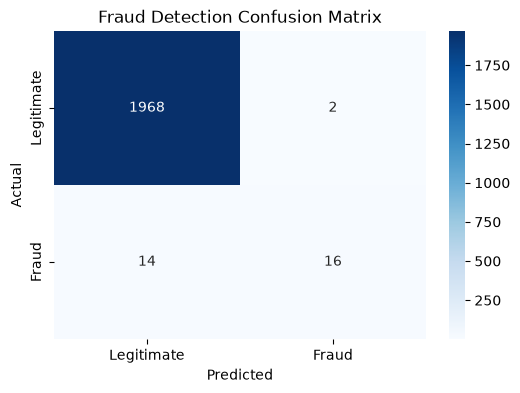

In [30]:
# Import the libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ctrate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Legitimate", "Fraud"], yticklabels=["Legitimate", "Fraud"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fraud Detection Confusion Matrix")
plt.show()

In [31]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get the probability of each transaction being fraudulent
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9943147208121828


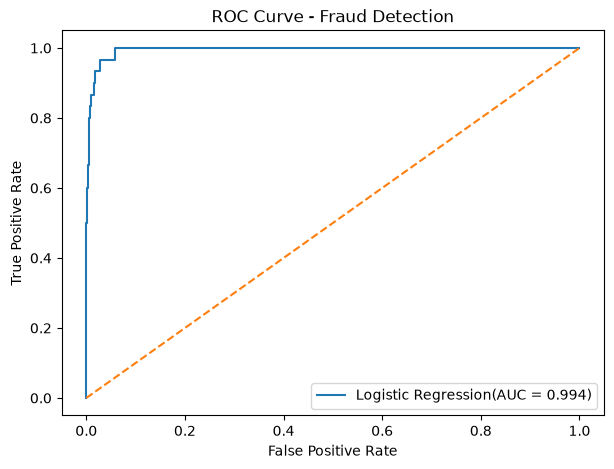

In [32]:
# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot the ROC curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Logistic Regression(AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection")
plt.legend()
plt.show()

In [34]:
# Create a summary of the model perormance
results = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"], "Score": [accuracy, precision, recall, f1, roc_auc]})
results

,Metric,Score
0,Accuracy,0.992000
1,Precision,0.888889
2,Recall,0.533333
3,F1-Score,0.666667
4,ROC-AUC,0.994315


In [36]:
# Display the metrics rounded to three decimal places
results["Score"] = results["Score"].round(3)
results

,Metric,Score
0,Accuracy,0.992
1,Precision,0.889
2,Recall,0.533
3,F1-Score,0.667
4,ROC-AUC,0.994


## Machine Learning Conclusion

A Logistic Regression classification model was developed to predict fraudulent credit card transactions. The dataset contained 10,000 transactions, with 151 identified as fraudulent, representing 1.51% of all transactions.

The data was divided into training and testing sets using stratified sampling to preserve the original class distribution. The `transaction_id` field was excluded because it is an identifier rather than a meaningful predictive feature, while the categorical `merchant_category` variable was converted into numerical features using one-hot encoding.

The model was evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Because the dataset is highly imbalanced, particular attention was given to precision, recall, F1-score, and ROC-AUC rather than relying on accuracy alone.

The results demonstrate how machine learning can be applied to identify potentially fraudulent transactions and support automated fraud detection. The model's performance should be interpreted in the context of the business cost of false positives and missed fraudulent transactions.

### Key Finding

The Logistic Regression model provides a baseline for fraud classification and demonstrates the potential of machine learning for detecting fraudulent transactions. Further improvement could involve testing additional classification algorithms and addressing class imbalance to improve fraud detection performance.
